# 1.3 CellAssign for EEC Subtypes

This notebook runs CellAssign on the subclustered EECs from 1.2_Reclustering_EECs.ipynb to label EEC subtypes.

In [1]:
import scanpy as sc
import scvi
import torch
from scvi.external import CellAssign
import pandas as pd
import numpy as np
from scipy import sparse

import matplotlib.pyplot as plt
import seaborn as sns
import palettable
import sys
from pathlib import Path
_p = Path(".").resolve()
while not (_p / "src" / "config.py").exists() and _p != _p.parent:
    _p = _p.parent
sys.path.insert(0, str(_p))
from src.config import ANALYSIS_DIR, DATA_DIR, FIGURES_DIR, UTILITIES_DIR


/opt/anaconda3/envs/single-cell-env/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
import os, sys


In [3]:
sc.settings.autosave = True
sc.settings.figdir = str(FIGURES_DIR / "cell-assign/d10-lapa")


### Load the subclustered EECs from 1.2

In [4]:

adata = sc.read_h5ad(ANALYSIS_DIR / "subclustered_EECs_egfDuod_D10_Lapa_DZ.h5ad")

In [5]:
adata

AnnData object with n_obs × n_vars = 1397 × 3000
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'freemuxlet.identity', 'participant', 'Condition', 'Time_point', 'Treatment', 'ident', 'leiden', 'leiden_subcluster'
    var: 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std', 'n_counts', 'highly_variable_rank', 'variances', 'variances_norm'
    uns: 'X_name', 'dendrogram_leiden_subcluster', 'hvg', 'leiden_colors', 'leiden_subcluster', 'leiden_subcluster_colors', 'log1p', 'neighbors', 'pca', 'umap'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    layers: 'counts'
    obsp: 'connectivities', 'distances'

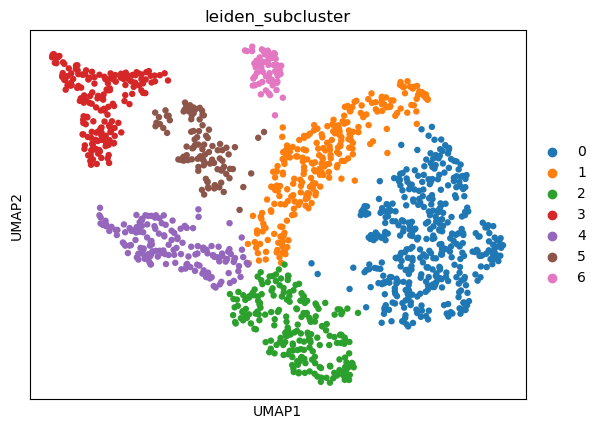

In [6]:
sc.pl.umap(adata, color='leiden_subcluster')

### Setup CellAssign

Load the EEC subtype marker matrix and prepare for CellAssign.

In [7]:
scvi.settings.seed = 0

Seed set to 0


In [8]:
# Load EEC subtype markers
eec_markers = pd.read_csv(UTILITIES_DIR / "eec_subtype_cellassign_markers.csv", index_col=0)
eec_markers

,NEUROG3+ PCs,Early EECs,X cells,D cells,I cells,K cells,Enterochromaffin cells
gene,,,,,,,
NEUROG3,1,0,0,0,0,0,0
HES1,0,1,0,0,0,0,0
ASCL2,0,1,0,0,0,0,0
ATOH1,0,1,0,0,0,0,0
PAX4,0,1,0,0,0,0,0
GHRL,0,0,1,0,0,0,0
SST,0,0,0,1,0,0,0
CCK,0,0,0,0,1,0,0
GIP,0,0,0,0,0,1,0


### Prepare data for CellAssign

We need to work with the raw counts layer and calculate size factors.

In [9]:
# Check which marker genes are present in our data
marker_genes = eec_markers.index.tolist()
present_genes = [g for g in marker_genes if g in adata.var_names]
missing_genes = [g for g in marker_genes if g not in adata.var_names]

print(f"Present genes ({len(present_genes)}): {present_genes}")
print(f"Missing genes ({len(missing_genes)}): {missing_genes}")

Present genes (11): ['NEUROG3', 'ASCL2', 'PAX4', 'GHRL', 'SST', 'CCK', 'GIP', 'CHGA', 'CHGB', 'SLC18A1', 'LMX1A']
Missing genes (2): ['HES1', 'ATOH1']


In [10]:
# Filter marker matrix to only include genes present in data
eec_markers_filtered = eec_markers.loc[present_genes]
eec_markers_filtered

,NEUROG3+ PCs,Early EECs,X cells,D cells,I cells,K cells,Enterochromaffin cells
gene,,,,,,,
NEUROG3,1,0,0,0,0,0,0
ASCL2,0,1,0,0,0,0,0
PAX4,0,1,0,0,0,0,0
GHRL,0,0,1,0,0,0,0
SST,0,0,0,1,0,0,0
CCK,0,0,0,0,1,0,0
GIP,0,0,0,0,0,1,0
CHGA,0,0,0,0,0,0,1
CHGB,0,0,0,0,0,0,1


In [11]:
# We need to reload from the original reclustered object to get all genes
# The subclustered object only has 3000 HVGs

# Load the original clustered data and subset to EECs
d10_lapa_dz_clustered = sc.read_h5ad(ANALYSIS_DIR / "clustered_egfDuod_D10_Lapa_DZ.h5ad")

# Subset to EEC cells (cluster 5 from original clustering)
clusters_to_keep = ["5"]
leiden_key = "leiden"
mask = d10_lapa_dz_clustered.obs[leiden_key].isin(clusters_to_keep)
EECs_full = d10_lapa_dz_clustered[mask].copy()

print(f"EECs with full gene set: {EECs_full.shape}")

EECs with full gene set: (1397, 28395)


In [12]:
# Check which marker genes are present in full data
present_genes_full = [g for g in marker_genes if g in EECs_full.var_names]
missing_genes_full = [g for g in marker_genes if g not in EECs_full.var_names]

print(f"Present genes ({len(present_genes_full)}): {present_genes_full}")
print(f"Missing genes ({len(missing_genes_full)}): {missing_genes_full}")

Present genes (13): ['NEUROG3', 'HES1', 'ASCL2', 'ATOH1', 'PAX4', 'GHRL', 'SST', 'CCK', 'GIP', 'CHGA', 'CHGB', 'SLC18A1', 'LMX1A']
Missing genes (0): []


In [13]:
# Filter marker matrix to only include genes present in data
eec_markers_filtered = eec_markers.loc[present_genes_full]
eec_markers_filtered

,NEUROG3+ PCs,Early EECs,X cells,D cells,I cells,K cells,Enterochromaffin cells
gene,,,,,,,
NEUROG3,1,0,0,0,0,0,0
HES1,0,1,0,0,0,0,0
ASCL2,0,1,0,0,0,0,0
ATOH1,0,1,0,0,0,0,0
PAX4,0,1,0,0,0,0,0
GHRL,0,0,1,0,0,0,0
SST,0,0,0,1,0,0,0
CCK,0,0,0,0,1,0,0
GIP,0,0,0,0,0,1,0


In [14]:
# Calculate size factors based on raw counts
lib_size = EECs_full.layers['counts'].sum(1)
if sparse.issparse(lib_size):
    lib_size = lib_size.A1
EECs_full.obs["size_factor"] = lib_size / np.mean(lib_size)

In [15]:
# Filter to marker genes for CellAssign
filtered_EECs = EECs_full[:, eec_markers_filtered.index].copy()
filtered_EECs

AnnData object with n_obs × n_vars = 1397 × 13
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'freemuxlet.identity', 'participant', 'Condition', 'Time_point', 'Treatment', 'ident', 'leiden', 'size_factor'
    var: 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
    uns: 'X_name', 'hvg'
    obsm: 'X_pca', 'X_umap'
    layers: 'counts'
    obsp: 'connectivities', 'distances'

In [16]:
# Setup CellAssign
scvi.external.CellAssign.setup_anndata(filtered_EECs, layer="counts", size_factor_key="size_factor")

### Train CellAssign model

In [17]:
eec_model = CellAssign(filtered_EECs, eec_markers_filtered)
eec_model.train()

/opt/anaconda3/envs/single-cell-env/lib/python3.11/site-packages/scvi/train/_trainrunner.py:84: UserWarning: `accelerator` has been automatically set to `cpu` although 'mps' exists. If you wish to run on mps backend, use explicitly accelerator='mps' in train function.In future releases it will become default for mps supported machines.
  accelerator, lightning_devices, device = parse_device_args(
GPU available: True (mps), used: False


TPU available: False, using: 0 TPU cores


HPU available: False, using: 0 HPUs


/opt/anaconda3/envs/single-cell-env/lib/python3.11/site-packages/lightning/pytorch/trainer/setup.py:177: GPU available but not used. You can set it by doing `Trainer(accelerator='gpu')`.
/opt/anaconda3/envs/single-cell-env/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:433: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=7` in the `DataLoader` to improve performance.
/opt/anaconda3/envs/single-cell-env/lib/python3.11/site-packages/lightning/pytorch/loops/fit_loop.py:310: The number of training batches (2) is smaller than the logging interval Trainer(log_every_n_steps=10). Set a lower value for log_every_n_steps if you want to see logs for the training epoch.
/opt/anaconda3/envs/single-cell-env/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:433: The 'val_dataloader' does not have many workers which may be a bo

Training:   0%|          | 0/400 [00:00<?, ?it/s]

...

Epoch 399/400: 100%|█████████▉| 399/400 [00:12<00:00, 30.99it/s, v_num=1, train_loss=16.8]

Epoch 400/400: 100%|█████████▉| 399/400 [00:12<00:00, 30.99it/s, v_num=1, train_loss=16.8]

Epoch 400/400: 100%|██████████| 400/400 [00:12<00:00, 30.99it/s, v_num=1, train_loss=16.8]

`Trainer.fit` stopped: `max_epochs=400` reached.


Epoch 400/400: 100%|██████████| 400/400 [00:12<00:00, 31.19it/s, v_num=1, train_loss=16.8]

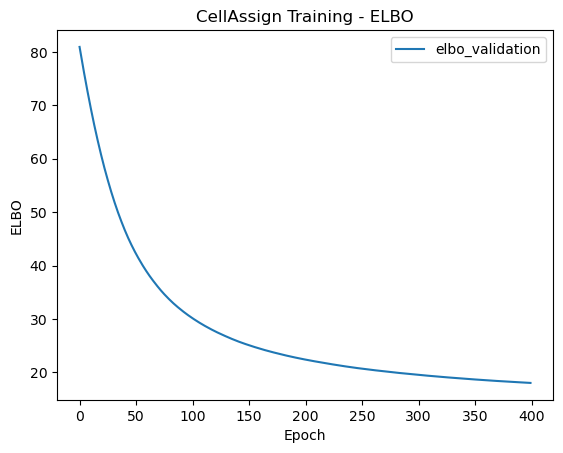

In [18]:
# Inspect the training history
eec_model.history["elbo_validation"].plot()
plt.title("CellAssign Training - ELBO")
plt.xlabel("Epoch")
plt.ylabel("ELBO")
plt.show()

### Get predictions

In [19]:
predictions = eec_model.predict()
predictions.head()

,NEUROG3+ PCs,Early EECs,X cells,D cells,I cells,K cells,Enterochromaffin cells
0,5.105480e-10,4.750280e-06,7.611437e-03,3.866917e-03,9.818093e-01,0.001425,0.005283
1,1.660415e-10,3.522645e-08,5.047803e-03,2.220094e-03,9.870507e-01,0.000497,0.005185
2,2.298352e-04,1.670264e-05,9.318083e-03,5.253782e-03,9.602023e-01,0.002348,0.022631
3,1.304299e-14,3.476774e-12,6.112372e-10,3.647859e-10,4.917582e-08,0.000004,0.999996
4,1.728797e-06,8.922652e-05,1.246890e-02,7.470856e-03,9.471404e-01,0.004356,0.028473


In [20]:
predictions.describe()

,NEUROG3+ PCs,Early EECs,X cells,D cells,I cells,K cells,Enterochromaffin cells
count,1.397000e+03,1.397000e+03,1.397000e+03,1.397000e+03,1.397000e+03,1.397000e+03,1397.000000
mean,5.461597e-02,3.437285e-05,5.718173e-02,6.313914e-02,4.481513e-01,7.700375e-03,0.369177
std,1.607015e-01,2.742810e-04,2.163280e-01,2.385538e-01,4.494074e-01,7.811683e-02,0.464776
min,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000
25%,2.259666e-28,1.760910e-29,1.762232e-24,2.235330e-17,4.173411e-23,2.474736e-26,0.003779
50%,1.589609e-10,3.697707e-07,3.820885e-03,1.746963e-03,3.451701e-01,2.309954e-04,0.021660
75%,1.951607e-06,1.236621e-05,8.308035e-03,4.348380e-03,9.667960e-01,1.424957e-03,1.000000
max,8.300085e-01,9.089885e-03,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000


In [21]:
# Store predictions in the subclustered adata object
# First, make sure indices match
predictions.index = filtered_EECs.obs_names

for col in predictions.columns:
    adata.obs[f"cellassign_prob_{col}"] = predictions.loc[adata.obs_names, col].values

adata.obs["cellassign_prediction"] = predictions.loc[adata.obs_names].idxmax(axis=1).values
adata.obs["cellassign_confidence"] = predictions.loc[adata.obs_names].max(axis=1).values

In [22]:
adata.obs['cellassign_prediction'].value_counts()

cellassign_prediction
I cells                   634
Enterochromaffin cells    512
D cells                    85
NEUROG3+ PCs               82
X cells                    74
K cells                    10
Name: count, dtype: int64

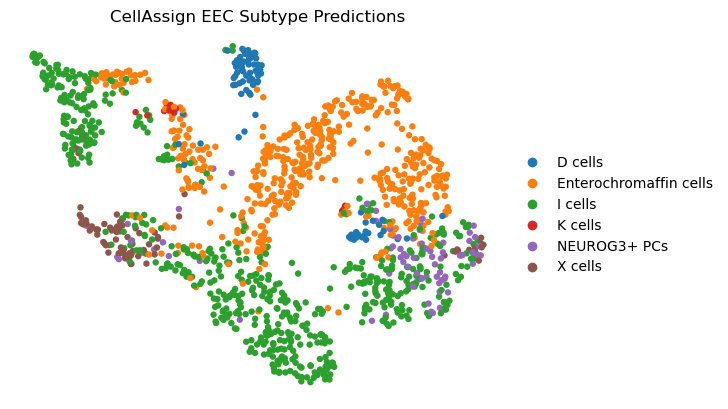

In [23]:
sc.pl.umap(
    adata,
    color="cellassign_prediction",
    frameon=False,
    title="CellAssign EEC Subtype Predictions"
)

/var/folders/gs/k55rgtm50g938k87mvcdclqr0000gq/T/ipykernel_14289/397513146.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(cluster_col)[prob_cols]


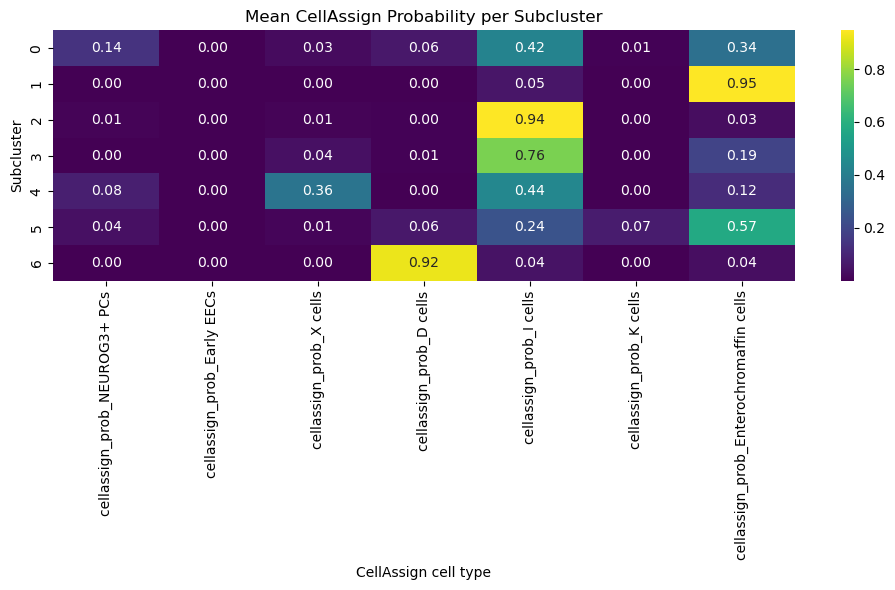

In [24]:
# Heatmap of predictions by subcluster
cluster_col = "leiden_subcluster"
prob_cols = [c for c in adata.obs.columns if c.startswith("cellassign_prob_")]

cluster_means = (
    adata.obs
    .groupby(cluster_col)[prob_cols]
    .mean()
)

plt.figure(figsize=(10, 6))
sns.heatmap(cluster_means, cmap="viridis", annot=True, fmt=".2f")
plt.title("Mean CellAssign Probability per Subcluster")
plt.xlabel("CellAssign cell type")
plt.ylabel("Subcluster")
plt.tight_layout()
plt.show()

---
## Custom Veres-style plotting

Reproduce the custom plotting from 1.4_EEC_subanalysis.ipynb

In [25]:
import matplotlib.gridspec as gridspec
import matplotlib.patches as patches
import matplotlib.patheffects as PathEffects
from collections import Counter, OrderedDict
from sklearn.neighbors import NearestNeighbors
from palettable.colorbrewer.qualitative import Set1_9, Paired_10, Set2_8
from scipy.sparse import issparse

In [26]:
# Typography to match paper
def setup_matplotlib_params():
    from matplotlib import rcParams
    rcParams['font.family'] = 'sans-serif'
    rcParams['font.sans-serif'] = ['Helvetica Neue', 'Arial', 'DejaVu Sans']
    rcParams['axes.titlesize'] = 5
    rcParams['axes.labelsize']  = 5
    rcParams['xtick.labelsize'] = 5
    rcParams['ytick.labelsize'] = 5
    rcParams['axes.linewidth']  = 0.5
    rcParams['xtick.major.width'] = 0.5
    rcParams['ytick.major.width'] = 0.5
    rcParams['pdf.fonttype'] = 42  # editable text in Illustrator

setup_matplotlib_params()

In [27]:
def _col(x): return np.array(x)/255.

class CoreColors:
    def __init__(self):
        base = dict(zip(
            ['red','blue','green','purple','orange','yellow','brown','pink','grey'],
            Set1_9.colors
        ))
        for k,v in base.items(): setattr(self, k, _col(v))
        for name,c in zip(['blue','green','red','orange','purple'], Paired_10.colors[::2]):
            setattr(self, 'pale_'+name, _col(c))
        self.teal        = _col(Set2_8.colors[0])
        self.pale_brown  = _col([193,128,108])
        self.light_grey  = _col(Set2_8.colors[-1])
        self.dark_green  = _col([52,117,50])
        self.dark_grey   = np.array([0.5,0.5,0.5])

core_colors = CoreColors()

In [28]:
def make_label_params(category_names):
    """
    Build a label->dict(color, short_label) map deterministically from the
    Veres palettes.
    """
    palette = (
        Set1_9.colors + Paired_10.colors[::2] + Set2_8.colors
    )
    lp = OrderedDict()
    for name, col in zip(category_names, palette):
        lp[name] = dict(color=_col(col), short_label=name)
    return lp

In [29]:
def prepare_for_scatter(X, labels, label_params):
    labels = np.asarray(labels)
    nbrs = NearestNeighbors(n_neighbors=5, algorithm='ball_tree').fit(X)
    knn = nbrs.kneighbors(X, return_distance=False)
    # fraction of neighbors with the same label; sort so dense/consistent are on top
    same = (labels[knn].T == labels[knn][:,0].T).mean(0)
    order = np.argsort(same)
    # map labels -> RGB
    colors = np.ones((len(labels),3))*0.5
    for k,v in label_params.items():
        colors[labels==k] = v['color']
    return X[order], colors[order]

In [30]:
def plot_veres_panel(
    adata,
    label_key,
    stage_text=None,
    ratio_order=None,
    label_order=None,
    save=None,
    dpi=600
):
    # coords & labels
    X = adata.obsm['X_umap']
    labels = adata.obs[label_key].astype(str).values
    cats = list(pd.unique(labels)) if label_order is None else label_order

    # label params (color + short label)
    lp = make_label_params(cats)

    # panel sizing
    mm_per_inch = 25.4
    panel_size_in = ((89/2)/mm_per_inch, 25.4/mm_per_inch)
    cell_pop_bar_h = 0.07
    heights = ((1 - cell_pop_bar_h)*panel_size_in[1], cell_pop_bar_h*panel_size_in[1])
    widths  = (panel_size_in[0] - heights[0], heights[0])

    fig = plt.figure(figsize=panel_size_in, dpi=dpi)
    gs  = gridspec.GridSpec(2, 2, fig, 0,0,1,1,
                            hspace=0, wspace=0,
                            width_ratios=widths, height_ratios=heights)

    # left column: title + legend
    ax = fig.add_subplot(gs[0,0], xticks=[], yticks=[], xlim=[0,1], ylim=[0,1], frameon=False)
    li = 1
    yl = lambda i: 1 - i/10.5
    xl_dot, xl_head, xl_text = 0.22, 0.30, 0.30

    if stage_text is None:
        stage_text = ""
    ax.text(xl_head, yl(li), f"{stage_text}", va='center', fontsize=6, fontweight='extra bold', clip_on=False)
    li += 1
    ax.text(xl_head, yl(li), f"({adata.n_obs:,} cells)", va='center', fontsize=5, clip_on=False)
    li += 1.5

    present = [c for c in (label_order or cats) if c in set(labels)]
    for lb in present:
        lb_txt = lp[lb]['short_label']
        ax.scatter(xl_dot, yl(li)+0.008, s=15, c=lp[lb]['color'].reshape(1,-1), clip_on=False)
        for line in str(lb_txt).splitlines():
            ax.text(xl_text, yl(li), line, va='center', fontsize=5, clip_on=False)
            li += 1

    # right column: scatter
    proj, rgb = prepare_for_scatter(X, labels, lp)
    ax = fig.add_subplot(gs[0,1], xticks=[], yticks=[], frameon=False, zorder=-1)
    ax.patch.set_visible(False)

    s_black, s_white, s_type = 4, 2, 1.5
    ax.scatter(proj[:,0], proj[:,1], c='k', edgecolor='none', s=s_black, rasterized=True)
    ax.scatter(proj[:,0], proj[:,1], c='w', edgecolor='none', s=s_white, rasterized=True)
    ax.scatter(proj[:,0], proj[:,1], c=rgb, edgecolor='none', s=s_type, alpha=0.7, rasterized=True)

    # bottom row: population ratio bar
    ax = fig.add_subplot(gs[1,0:2], xticks=[], yticks=[], xlim=[0,1], ylim=[0,1], frameon=False)

    counts = pd.Series(Counter(labels))
    fracs  = counts / counts.sum()
    rr = ratio_order or present

    cumul = 0.0
    for lb in rr:
        if lb in fracs:
            w = float(fracs[lb])
            ax.add_patch(patches.Rectangle((0.30 + 0.68*cumul, 0.02), 0.68*w, 1.0,
                                           facecolor=lp[lb]['color'], edgecolor='none', clip_on=False))
            cumul += w

    ax.text(0.175, 0.5, 'Pop. ratios:', va='center', ha='center', fontsize=5, clip_on=False)
    ax.add_patch(patches.Rectangle((0.30, 0.02), 0.68, 1.0, facecolor='none', edgecolor='k', linewidth=0.5, clip_on=False))

    plt.tight_layout()
    if save:
        fig.savefig(save, dpi=dpi, transparent=True, bbox_inches='tight')
    return fig

### Plot CellAssign predictions with Veres-style panel

/var/folders/gs/k55rgtm50g938k87mvcdclqr0000gq/T/ipykernel_14289/1345112558.py:79: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


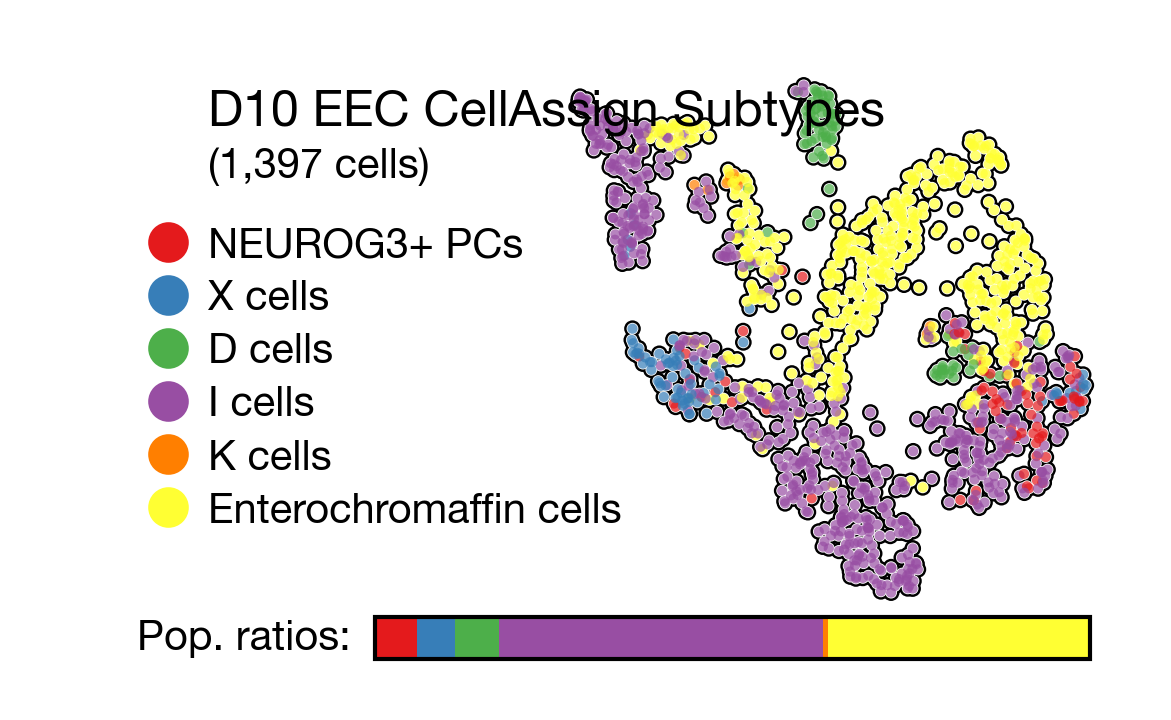

In [31]:
LABEL_KEY = "cellassign_prediction"

# Get unique labels and define order
label_order = [
    "NEUROG3+ PCs", "Early EECs", "X cells", "D cells", 
    "I cells", "K cells", "Enterochromaffin cells"
]
# Filter to only labels present in data
label_order = [l for l in label_order if l in adata.obs[LABEL_KEY].unique()]

fig = plot_veres_panel(
    adata, 
    label_key=LABEL_KEY,
    stage_text="D10 EEC CellAssign Subtypes",
    label_order=label_order,
    ratio_order=label_order,
    save="D10_EEC_cellassign_subtypes.pdf"
)

### Plot EEC markers on UMAP

In [32]:
Enterochromaffin_markers = ["CHGA", "TPH1", "NEUROD1"]
Peptide_cell_markers = ["ARX", "MLN", "GHRL", "GIP", "CCK"]
More_Peptide_cell_markers = ["GCG", "PYY", "SST", "GAST", "NTS"]

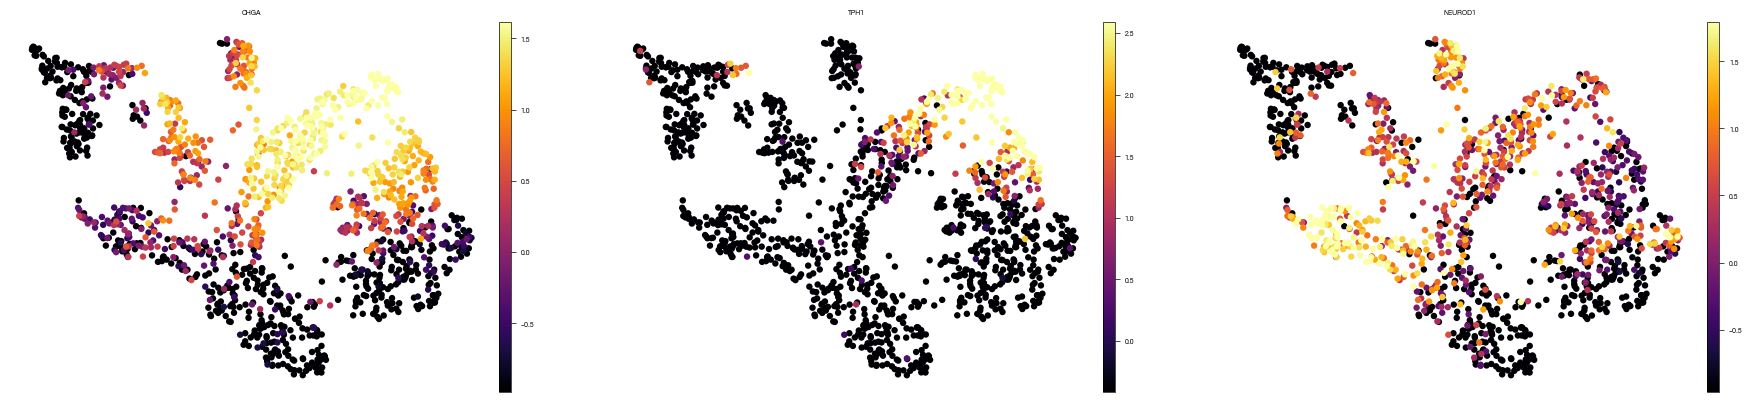

In [33]:
present = [g for g in Enterochromaffin_markers
           if (hasattr(adata, "raw") and adata.raw is not None and g in adata.raw.var_names) or
              (g in adata.var_names)]

sc.pl.umap(
    adata,
    color=present,
    ncols=4,
    cmap="inferno",
    vmax="p95",
    frameon=False
)

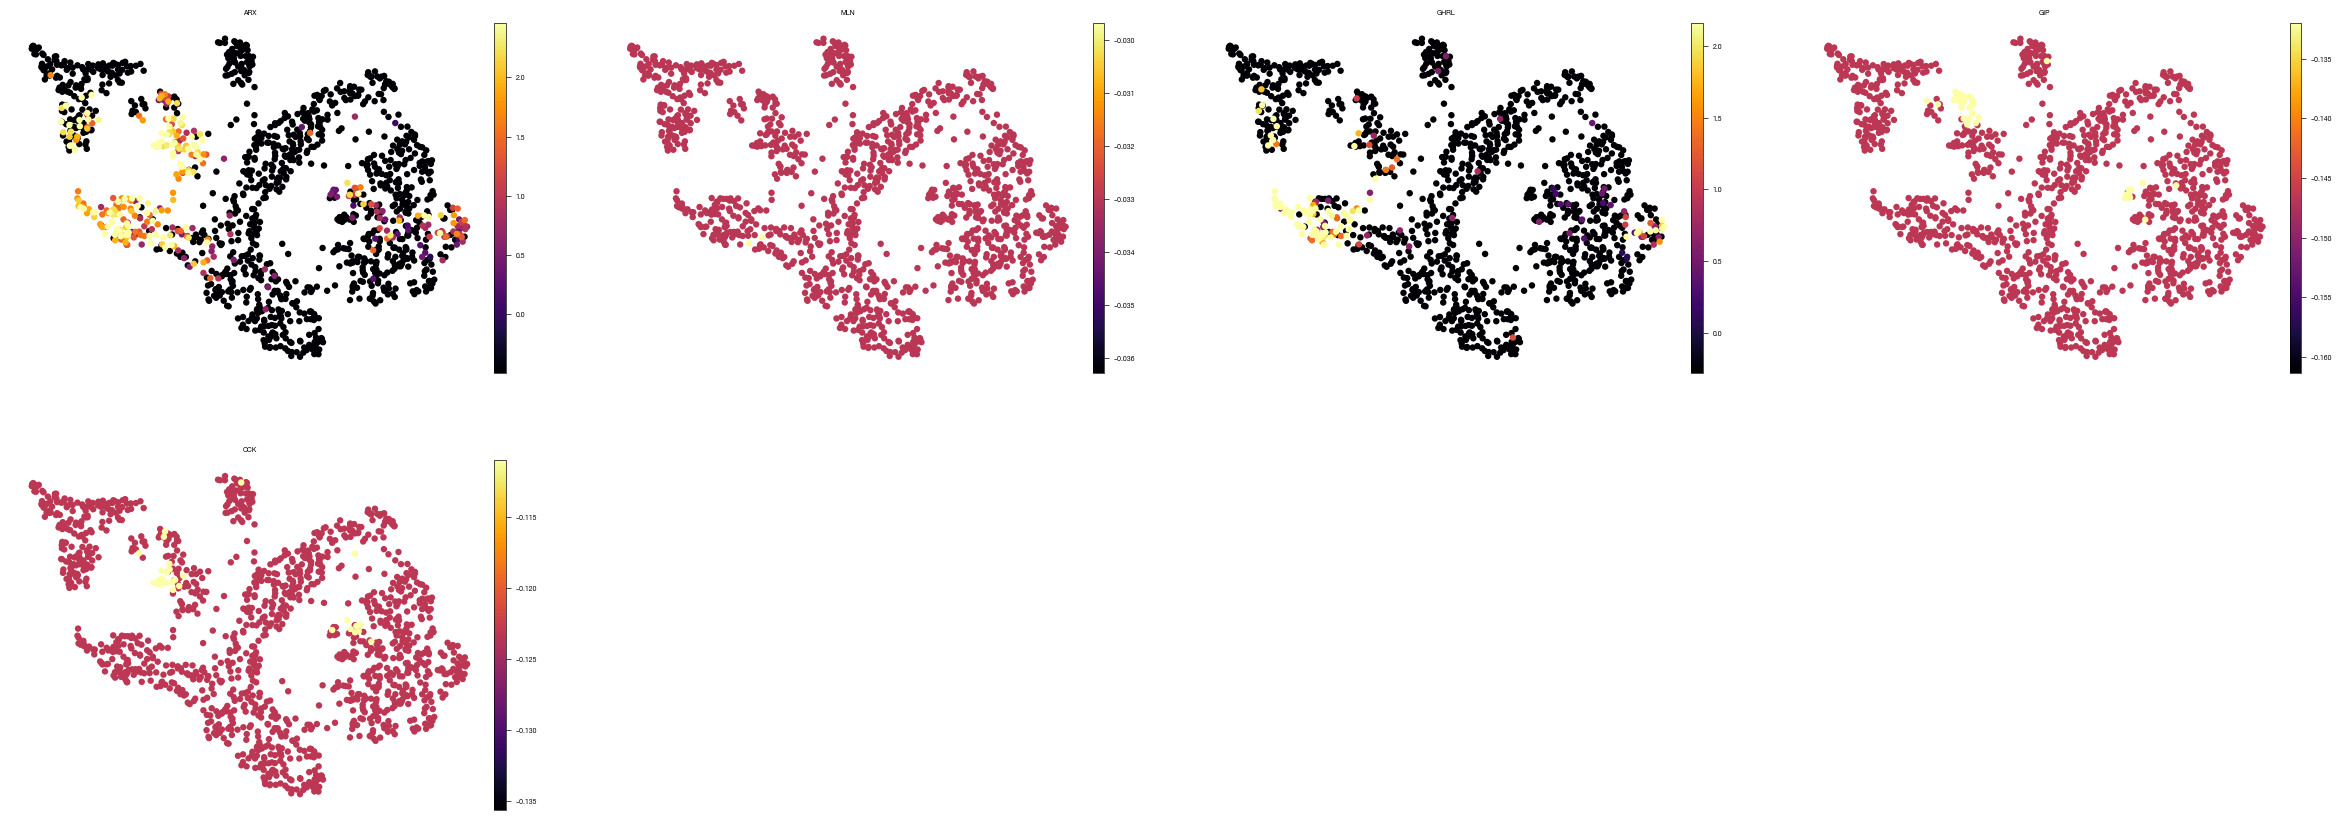

In [34]:
present = [g for g in Peptide_cell_markers
           if (hasattr(adata, "raw") and adata.raw is not None and g in adata.raw.var_names) or
              (g in adata.var_names)]

sc.pl.umap(
    adata,
    color=present,
    ncols=4,
    cmap="inferno",
    vmax="p95",
    frameon=False
)

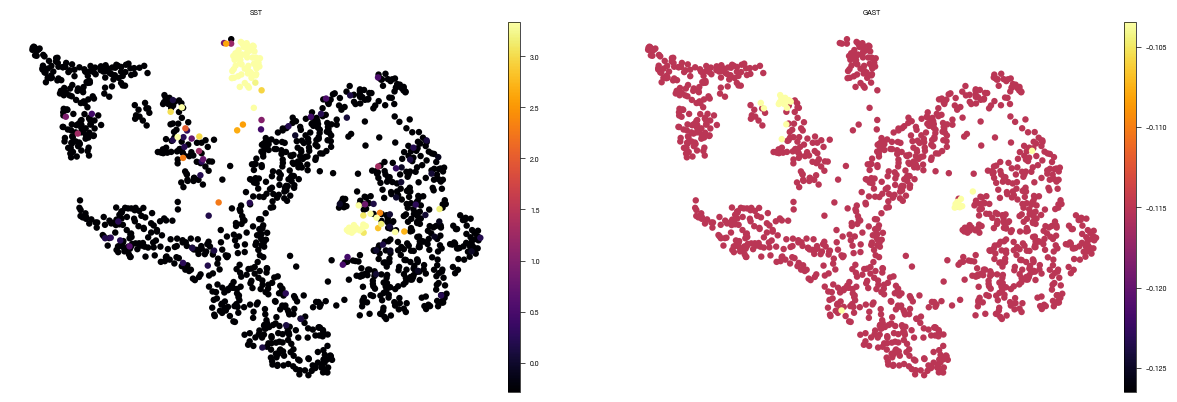

In [35]:
present = [g for g in More_Peptide_cell_markers
           if (hasattr(adata, "raw") and adata.raw is not None and g in adata.raw.var_names) or
              (g in adata.var_names)]

sc.pl.umap(
    adata,
    color=present,
    ncols=4,
    cmap="inferno",
    vmax="p95",
    frameon=False
)

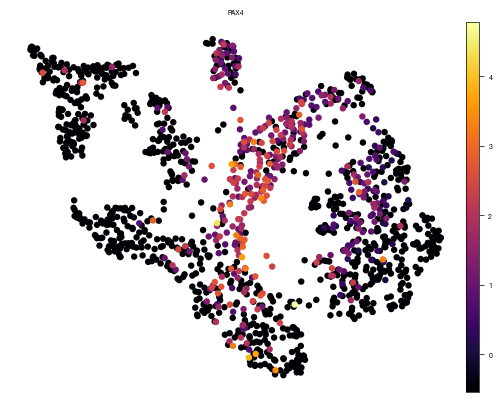

In [36]:
sc.pl.umap(
    adata,
    color="PAX4",
    cmap="inferno",
    frameon=False
)

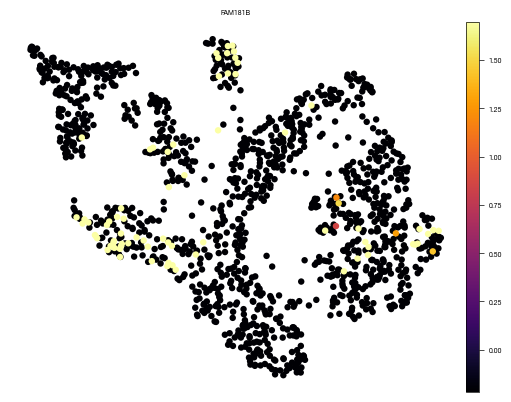

In [37]:
Cofactors = ["PERCC1", "FAM181B"]

present = [g for g in Cofactors
           if (hasattr(adata, "raw") and adata.raw is not None and g in adata.raw.var_names) or
              (g in adata.var_names)]

sc.pl.umap(
    adata,
    color=present,
    ncols=4,
    vmax="p95",
    cmap="inferno",
    frameon=False
)

### Save the annotated object

In [38]:
intermediate_directory = str(ANALYSIS_DIR)
sc.write(f'{intermediate_directory}/cellassign_EECs_egfDuod_D10_Lapa_DZ.h5ad', adata)

In [39]:
adata.obs[['leiden_subcluster', 'cellassign_prediction', 'cellassign_confidence']].head(20)

,leiden_subcluster,cellassign_prediction,cellassign_confidence
AAACCATTCCGCATCC-1,2,I cells,0.981809
AAACCGCTCTGTCTAC-1,0,I cells,0.987051
AAACGAATCTAATGAC-1,0,I cells,0.960202
AAACGCCTCCATAGTG-1,5,Enterochromaffin cells,0.999996
AAACGCCTCGCATCAA-1,5,I cells,0.947140
AAACGGACAATCAGTA-1,3,I cells,0.962946
AAACGGACATTAGCAA-1,4,I cells,0.932881
AAACGTAAGCGATGAG-1,2,NEUROG3+ PCs,0.532924
AAACGTCCATCCCTAA-1,0,I cells,0.984942
AAACTCACATCCTTGA-1,4,I cells,0.970440
